In [160]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [162]:
# 2. LOAD DATA
df = pd.read_csv('shopping_behavior_updated.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 3900 rows × 18 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [164]:
# 3. DATA EXPLORATION
# 3.1 Dataset structure
print('DATASET INFORMATION')
df.info()

# 3.2 Statistical summary
print('STATISTICAL SUMMARY')
df.describe(include='all').round(2)

# 3.3 Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('MISSING VALUES')
print(missing_df[missing_df['Missing Count'] > 0])

# 3.4 Duplicate check
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# 3.5 Verify data types
print('DATA TYPES')
print(df.dtypes)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used     

In [166]:
# 4. DATA CLEANING
# 4.1 Standardise column names
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

print('Columns standardised:')
print(df.columns.tolist())

# 4.2 Remove redundant column
# promo_code_used is identical to discount_applied 
df = df.drop(columns=['promo_code_used'])
print(f'Columns remaining: {df.shape}')

print(df.dtypes)

Columns standardised:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']
Columns remaining: (3900, 17)
customer_id                 int64
age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount             int64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
subscription_status        object
shipping_type              object
discount_applied           object
previous_purchases          int64
payment_method             object
frequency_of_purchases     object
dtype: object


In [168]:
# 5. FEATURE ENGINEERING
# 5.1 Age group
labels = ['Young Adult (18-30)', 'Adult (31-45)', 'Mid-aged (46-57)', 'Senior (58-70)']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)
df['age_group'].value_counts().sort_index()

age_group
Young Adult (18-30)    1028
Adult (31-45)           942
Mid-aged (46-57)        986
Senior (58-70)          944
Name: count, dtype: int64

In [170]:
# 5.2 Purchase frequency in days
frequency_mapping = {
    'Weekly': 7, 'Fortnightly': 14, 'Bi-Weekly': 14,
    'Monthly': 30, 'Every 3 Months': 90, 'Quarterly': 90, 'Annually': 365
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)
df[['frequency_of_purchases', 'purchase_frequency_days']].drop_duplicates().sort_values('purchase_frequency_days')

,frequency_of_purchases,purchase_frequency_days
2,Weekly,7
0,Fortnightly,14
10,Bi-Weekly,14
15,Monthly,30
6,Quarterly,90
20,Every 3 Months,90
4,Annually,365


In [172]:
# 5.3 Spend tier
def spend_tier(amount):
    if amount <= 40:
        return 'Low Spender'
    elif amount <= 70:
        return 'Mid Spender'
    else:
        return 'High Spender'

df['spend_tier'] = df['purchase_amount'].apply(spend_tier)
df['spend_tier'].value_counts()

spend_tier
High Spender    1447
Mid Spender     1393
Low Spender     1060
Name: count, dtype: int64

In [174]:
# 5.4 Loyalty stage
def loyalty_stage(purchases):
    if purchases <= 2:
        return '1_New'
    elif purchases <= 10:
        return '2_Returning'
    elif purchases <= 25:
        return '3_Established'
    else:
        return '4_Loyal'

df['loyalty_stage'] = df['previous_purchases'].apply(loyalty_stage)
df['loyalty_stage'].value_counts().sort_index()

# Preview all new features
df[['age', 'age_group', 'purchase_amount', 'spend_tier',
    'frequency_of_purchases', 'purchase_frequency_days',
    'previous_purchases', 'loyalty_stage']].head(8)

,age,age_group,purchase_amount,spend_tier,frequency_of_purchases,purchase_frequency_days,previous_purchases,loyalty_stage
0,55,Mid-aged (46-57),53,Mid Spender,Fortnightly,14,14,3_Established
1,19,Young Adult (18-30),64,Mid Spender,Fortnightly,14,2,1_New
2,50,Mid-aged (46-57),73,High Spender,Weekly,7,23,3_Established
3,21,Young Adult (18-30),90,High Spender,Weekly,7,49,4_Loyal
4,45,Mid-aged (46-57),49,Mid Spender,Annually,365,31,4_Loyal
5,46,Mid-aged (46-57),20,Low Spender,Weekly,7,14,3_Established
6,63,Senior (58-70),85,High Spender,Quarterly,90,49,4_Loyal
7,27,Young Adult (18-30),34,Low Spender,Weekly,7,19,3_Established


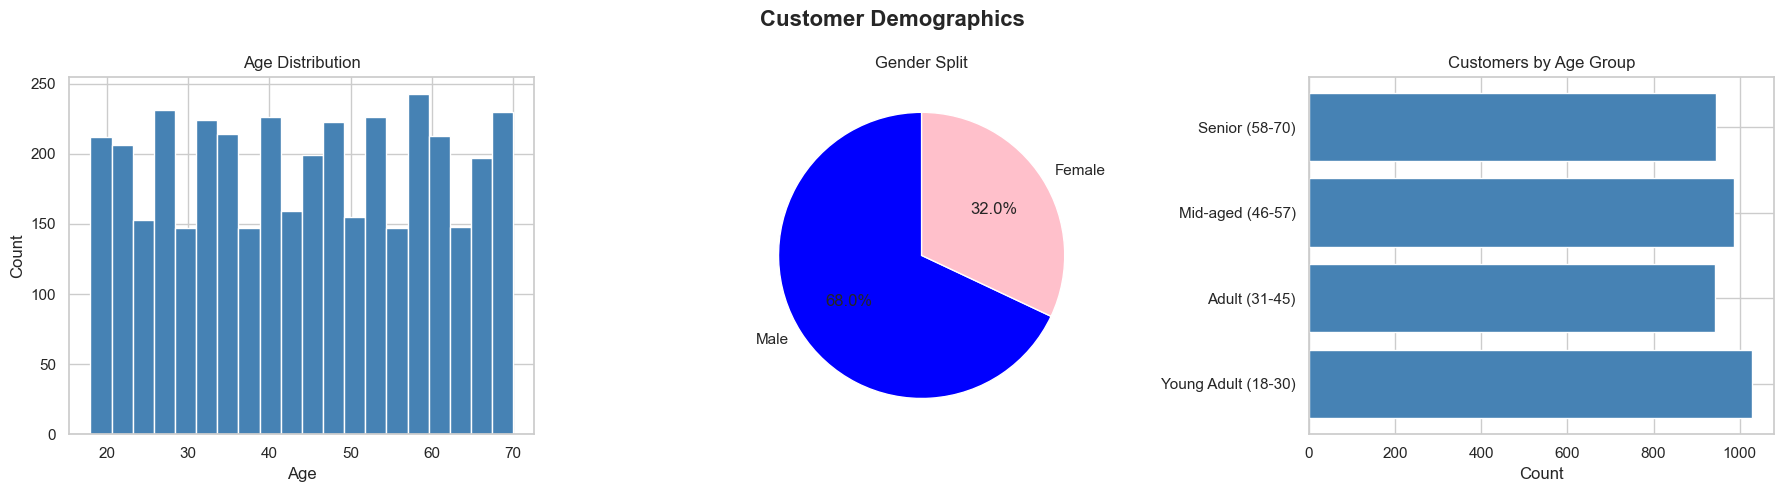

In [240]:
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# 6.1 Customer Demographics Overview
plt.figure(figsize=(18, 5))
plt.suptitle('Customer Demographics', fontsize=16, fontweight='bold')

plt.subplot(1, 3, 1)
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index,
        autopct='%1.1f%%', colors=['Blue', 'Pink'], startangle=90)
plt.title('Gender Split')

plt.subplot(1, 3, 3)
age_counts = df['age_group'].value_counts().sort_index()
plt.barh(age_counts.index.astype(str), age_counts.values, color='steelblue')
plt.title('Customers by Age Group')
plt.xlabel('Count')

plt.tight_layout()
plt.savefig('eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

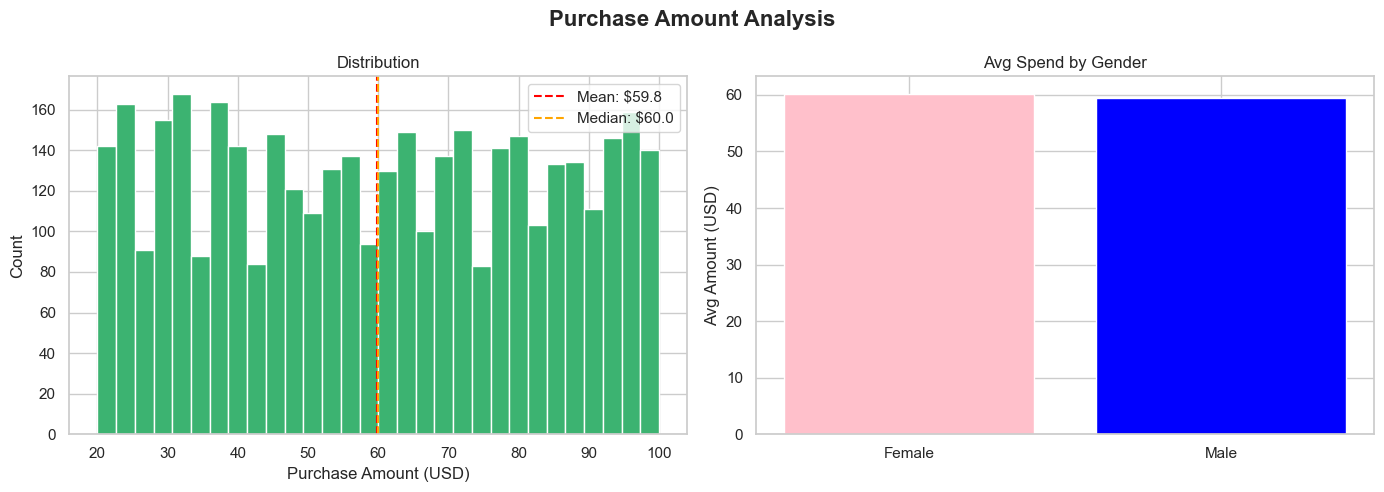

In [232]:
# 6.2 Purchase amount Analysis
plt.figure(figsize=(14, 5))
plt.suptitle('Purchase Amount Analysis', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
plt.hist(df['purchase_amount'], bins=30, color='mediumseagreen', edgecolor='white')
plt.axvline(df['purchase_amount'].mean(), color='red', linestyle='--',
            label=f"Mean: ${df['purchase_amount'].mean():.1f}")
plt.axvline(df['purchase_amount'].median(), color='orange', linestyle='--',
            label=f"Median: ${df['purchase_amount'].median():.1f}")
plt.title('Distribution')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
gender_spend = df.groupby('gender')['purchase_amount'].mean()
plt.bar(gender_spend.index, gender_spend.values,
        color=['Pink', 'Blue'], edgecolor='white')
plt.title('Avg Spend by Gender')
plt.ylabel('Avg Amount (USD)')

plt.tight_layout()
plt.savefig('eda_purchase_amount.png', dpi=150, bbox_inches='tight')
plt.show()

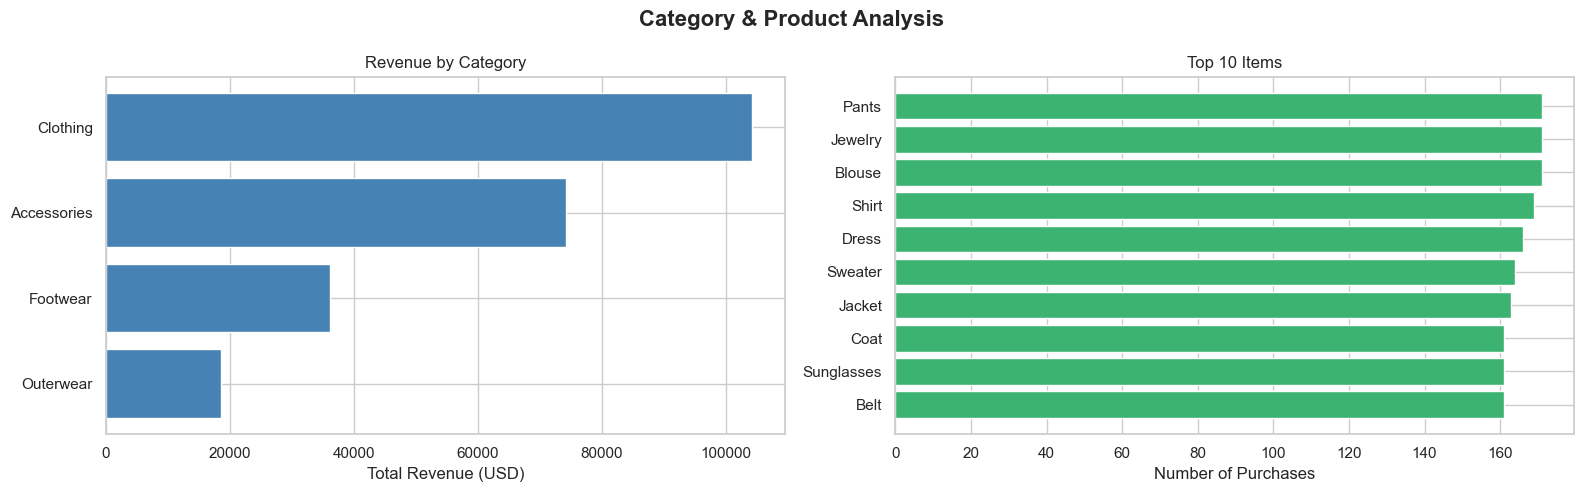

Top category: Clothing


In [178]:
# 6.3 Category & product
plt.figure(figsize=(16, 5))
plt.suptitle('Category & Product Analysis', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
cat_revenue = df.groupby('category')['purchase_amount'].sum().sort_values()
plt.barh(cat_revenue.index, cat_revenue.values, color='steelblue', edgecolor='white')
plt.title('Revenue by Category')
plt.xlabel('Total Revenue (USD)')

plt.subplot(1, 2, 2)
top_items = df['item_purchased'].value_counts().head(10).sort_values()
plt.barh(top_items.index, top_items.values, color='mediumseagree', edgecolor='white')
plt.title('Top 10 Items')
plt.xlabel('Number of Purchases')

plt.tight_layout()
plt.savefig('eda_category_product.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top category: {cat_revenue.idxmax()}')

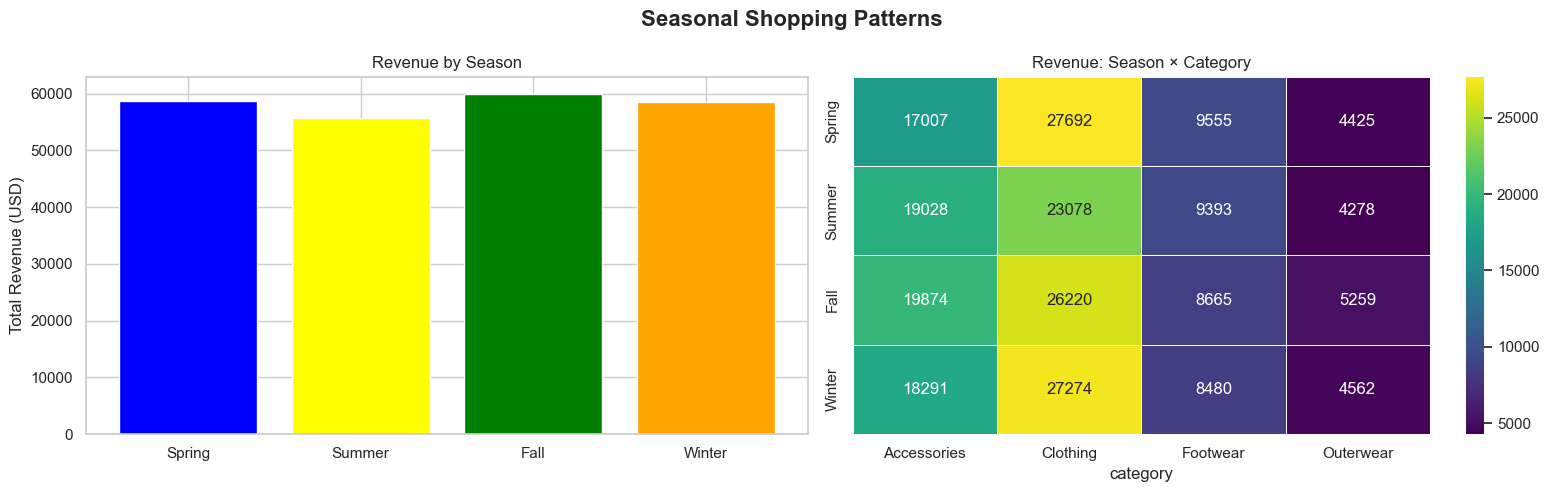

Best season: Fall


In [228]:
# 6.4 Seasonal analysis
plt.figure(figsize=(16, 5))
plt.suptitle('Seasonal Shopping Patterns', fontsize=16, fontweight='bold')

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_rev = df.groupby('season')['purchase_amount'].sum().reindex(season_order)

plt.subplot(1, 2, 1)
plt.bar(season_rev.index, season_rev.values,
        color=['Blue', 'Yellow', 'Green', 'Orange'], edgecolor='white')
plt.title('Revenue by Season')
plt.ylabel('Total Revenue (USD)')

plt.subplot(1, 2, 2)
season_cat = df.groupby(['season', 'category'])['purchase_amount'].sum().unstack().reindex(season_order)
sns.heatmap(season_cat, annot=True, fmt='.0f', cmap='viridis', linewidths=0.5)
plt.title('Revenue: Season × Category')
plt.ylabel('')

plt.tight_layout()
plt.savefig('eda_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best season: {season_rev.idxmax()}')

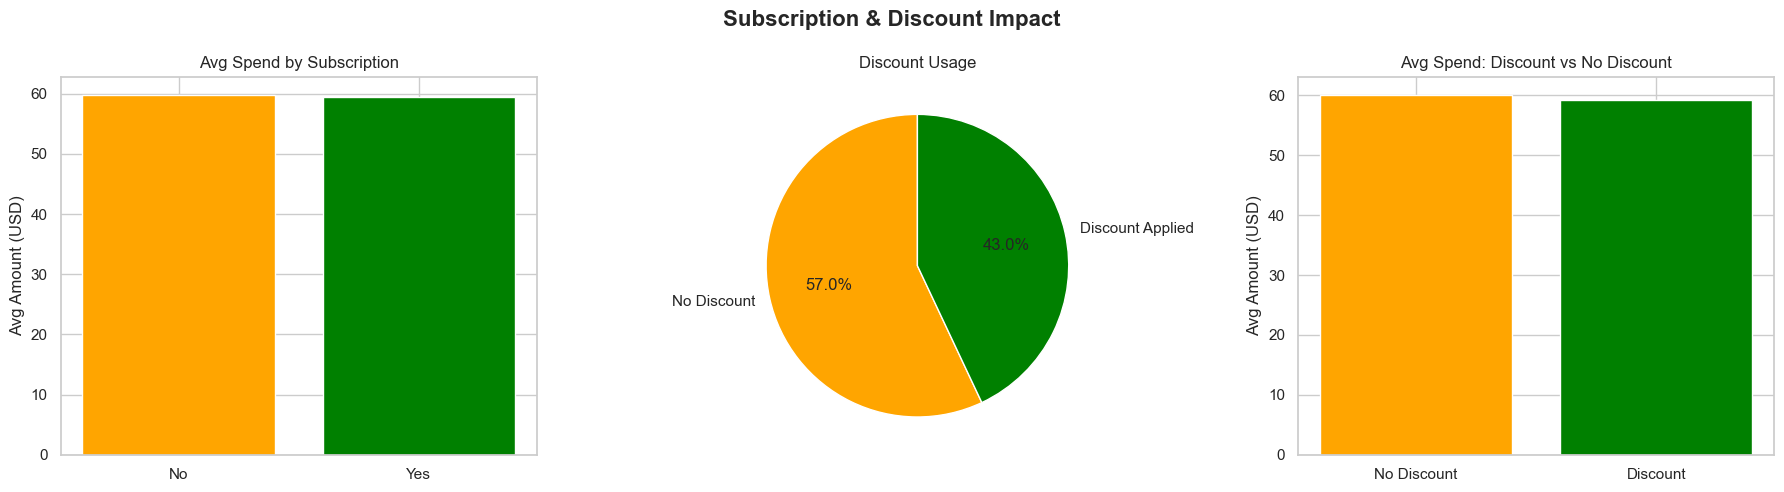

In [242]:
# 6.5 Subscription & discount
plt.figure(figsize=(18, 5))
plt.suptitle('Subscription & Discount Impact', fontsize=16, fontweight='bold')

plt.subplot(1, 3, 1)
sub_spend = df.groupby('subscription_status')['purchase_amount'].mean()
plt.bar(sub_spend.index, sub_spend.values,
        color=['Orange', 'Green'], edgecolor='white')
plt.title('Avg Spend by Subscription')
plt.ylabel('Avg Amount (USD)')

plt.subplot(1, 3, 2)
discount_counts = df['discount_applied'].value_counts()
plt.pie(discount_counts, labels=['No Discount', 'Discount Applied'],
        autopct='%1.1f%%', colors=['Orange', 'Green'], startangle=90)
plt.title('Discount Usage')

plt.subplot(1, 3, 3)
disc_spend = df.groupby('discount_applied')['purchase_amount'].mean()
plt.bar(disc_spend.index, disc_spend.values,
        color=['Orange', 'Green'])
plt.title('Avg Spend: Discount vs No Discount')
plt.ylabel('Avg Amount (USD)')
plt.xticks(ticks=range(len(disc_spend)), labels=['No Discount', 'Discount'])

plt.tight_layout()
plt.savefig('eda_subscription_discount.png', dpi=150, bbox_inches='tight')
plt.show()

In [186]:
# 7. RFM ANALYSIS
# 7.1 Calculate RFM scores
# Build RFM table
rfm = df[['customer_id', 'purchase_frequency_days',
          'previous_purchases', 'purchase_amount']].copy()
rfm.columns = ['customer_id', 'recency_days', 'frequency', 'monetary']

rfm['r_score'] = pd.qcut(rfm['recency_days'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print('Score range:', rfm['rfm_score'].min(), '–', rfm['rfm_score'].max())
rfm.head()

Score range: 3 – 12


,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score
0,1,14,14,53,4,2,2,8
1,2,14,2,64,4,1,3,8
2,3,7,23,73,4,2,3,9
3,4,7,49,90,4,4,4,12
4,5,365,31,49,1,3,2,6


In [188]:
# 7.2 Assign RFM segments
def rfm_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['rfm_segment'] = rfm['rfm_score'].apply(rfm_segment)
print(rfm['rfm_segment'].value_counts())

df = df.merge(rfm[['customer_id', 'r_score', 'f_score', 'm_score',
                    'rfm_score', 'rfm_segment']], on='customer_id', how='left')

rfm_segment
Loyal Customers        1407
Potential Loyalists    1243
Champions               787
At Risk                 429
Lost                     34
Name: count, dtype: int64


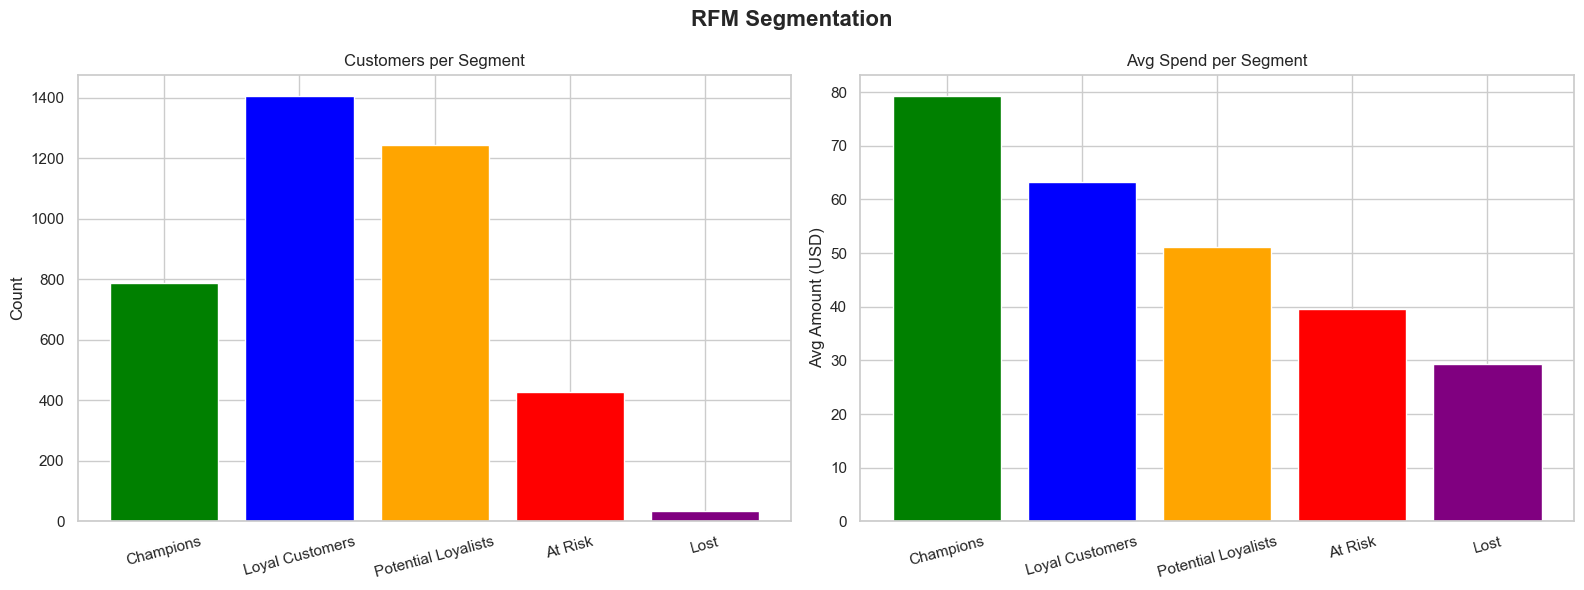

In [220]:
# 7.3 Visualise RFM
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
colors = ['Green', 'Blue', 'Orange', 'Red', 'Purple']

plt.figure(figsize=(16, 6))
plt.suptitle('RFM Segmentation', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
seg_counts = rfm['rfm_segment'].value_counts().reindex(segment_order)
plt.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
plt.title('Customers per Segment')
plt.ylabel('Count')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
seg_value = rfm.groupby('rfm_segment')['monetary'].mean().reindex(segment_order)
plt.bar(seg_value.index, seg_value.values, color=colors, edgecolor='white')
plt.title('Avg Spend per Segment')
plt.ylabel('Avg Amount (USD)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [192]:
# 8. CUSTOMER SEGMENTATION (K-Means)

In [194]:
# 8.1 Scale features
features = df[['age', 'purchase_amount', 'previous_purchases', 'purchase_frequency_days']].copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
print('Scaled shape:', scaled.shape)

Scaled shape: (3900, 4)


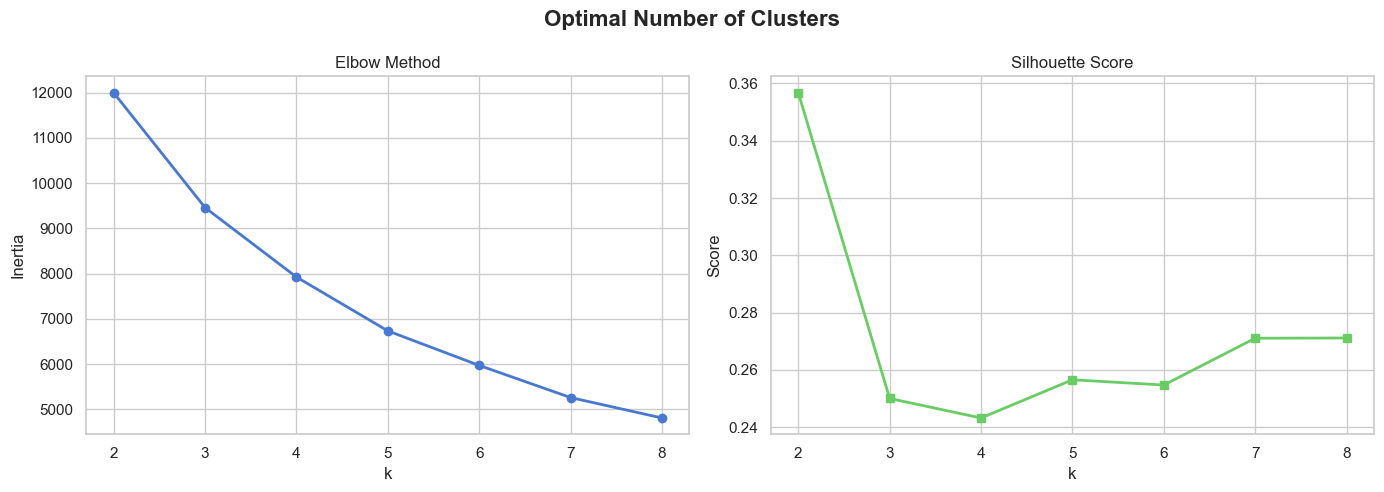

Selected k: 3


In [196]:
# 8.2 Find optimal k - Elbow + Silhouette
inertia, sil_scores = [], []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled, km.labels_))

plt.figure(figsize=(14, 5))
plt.suptitle('Optimal Number of Clusters', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-', linewidth=2)
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 'gs-', linewidth=2)
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()



In [198]:
# k=2 peaks mathematically but too broad for business use
# k=3 gives Low / Mid / High value segments
best_k = 3
print(f'Selected k: {best_k}')

Selected k: 3


In [200]:
# 8.3 Fit and profile clusters
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(scaled)

cluster_profile = df.groupby('cluster').agg(
    customers=('customer_id', 'count'),
    avg_age=('age', 'mean'),
    avg_spend=('purchase_amount', 'mean'),
    avg_purchases=('previous_purchases', 'mean'),
    avg_freq_days=('purchase_frequency_days', 'mean')
).round(1)

print(cluster_profile)

         customers  avg_age  avg_spend  avg_purchases  avg_freq_days
cluster                                                             
0             1681     45.8       60.5           37.8           41.9
1             1647     42.0       58.8           12.9           41.5
2              572     44.7       60.2           24.6          365.0


In [202]:
# 8.4 Label clusters — review profile above and adjust if needed
cluster_labels = {}
for i in range(best_k):
    row = cluster_profile.loc[i]
    if row['avg_spend'] >= 65 and row['avg_purchases'] >= 25:
        cluster_labels[i] = 'High Value'
    elif row['avg_freq_days'] <= 14 and row['avg_purchases'] >= 15:
        cluster_labels[i] = 'Frequent Buyer'
    elif row['avg_spend'] <= 40:
        cluster_labels[i] = 'Budget Shopper'
    else:
        cluster_labels[i] = 'Mid Range'

df['cluster_label'] = df['cluster'].map(cluster_labels)
print(df['cluster_label'].value_counts())

cluster_label
Mid Range    3900
Name: count, dtype: int64


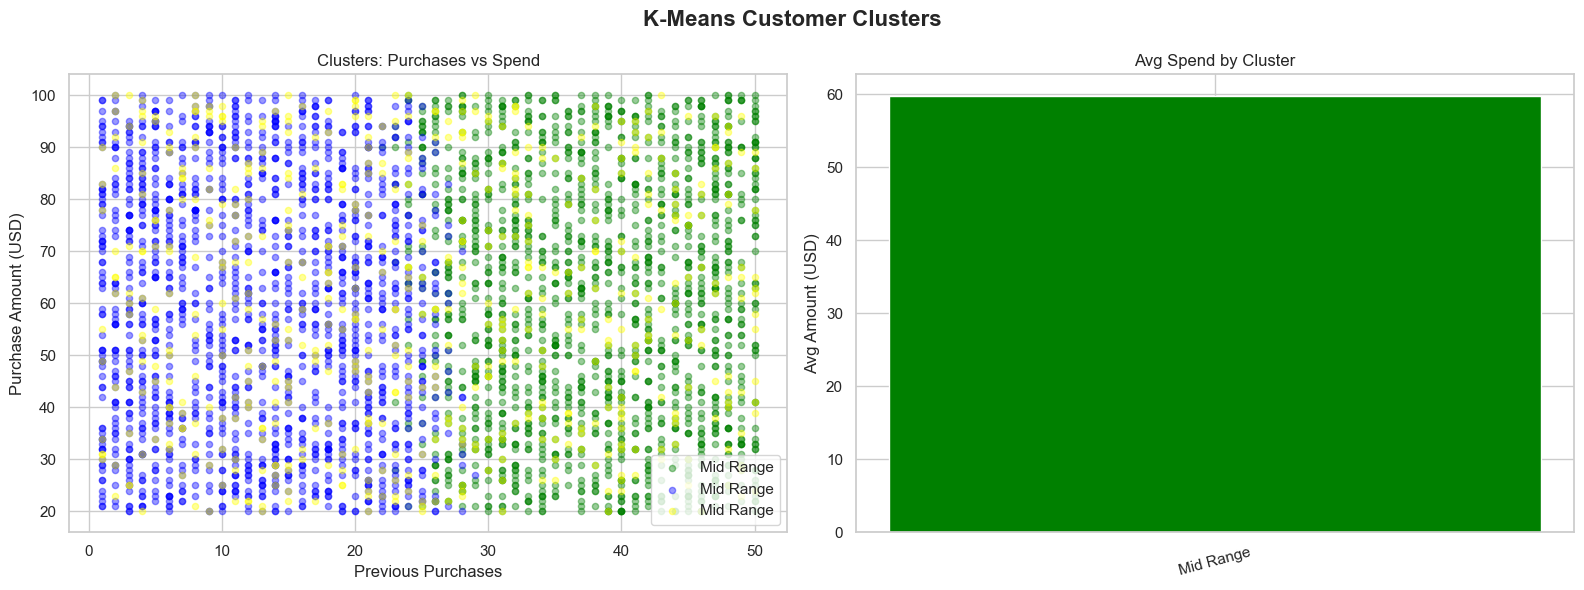

In [218]:
# 8.5  Visualise clusters
hex_colors = ['Green', 'Blue', 'Yellow']

plt.figure(figsize=(16, 6))
plt.suptitle('K-Means Customer Clusters', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
for i, label in cluster_labels.items():
    mask = df['cluster'] == i
    plt.scatter(df[mask]['previous_purchases'], df[mask]['purchase_amount'],
                alpha=0.4, label=label, s=20, color=hex_colors[i])
plt.title('Clusters: Purchases vs Spend')
plt.xlabel('Previous Purchases')
plt.ylabel('Purchase Amount (USD)')
plt.legend()

plt.subplot(1, 2, 2)
cluster_spend = df.groupby('cluster_label')['purchase_amount'].mean().sort_values(ascending=False)
bar_colors = [hex_colors[list(cluster_labels.values()).index(l)] for l in cluster_spend.index]
plt.bar(cluster_spend.index, cluster_spend.values, color=bar_colors, edgecolor='white')
plt.title('Avg Spend by Cluster')
plt.ylabel('Avg Amount (USD)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [206]:
# 9. COHORT ANALYSIS
# 9.1 Cohort summary
cohort = df.groupby('loyalty_stage').agg(
    customers=('customer_id', 'count'),
    avg_spend=('purchase_amount', 'mean'),
    avg_rating=('review_rating', 'mean'),
    subscription_rate=('subscription_status', lambda x: (x == 'Yes').mean() * 100),
    discount_rate=('discount_applied', lambda x: (x == 'Yes').mean() * 100)
).round(2).sort_index()

cohort.columns = ['Customers', 'Avg Spend ($)', 'Avg Rating', 'Subscription %', 'Discount %']
print(cohort)

               Customers  Avg Spend ($)  Avg Rating  Subscription %  \
loyalty_stage                                                         
1_New                155          59.34        3.78           20.65   
2_Returning          629          61.00        3.78           24.17   
3_Established       1181          58.90        3.73           27.43   
4_Loyal             1935          59.93        3.75           28.17   

               Discount %  
loyalty_stage              
1_New               40.65  
2_Returning         40.38  
3_Established       44.71  
4_Loyal             43.00  


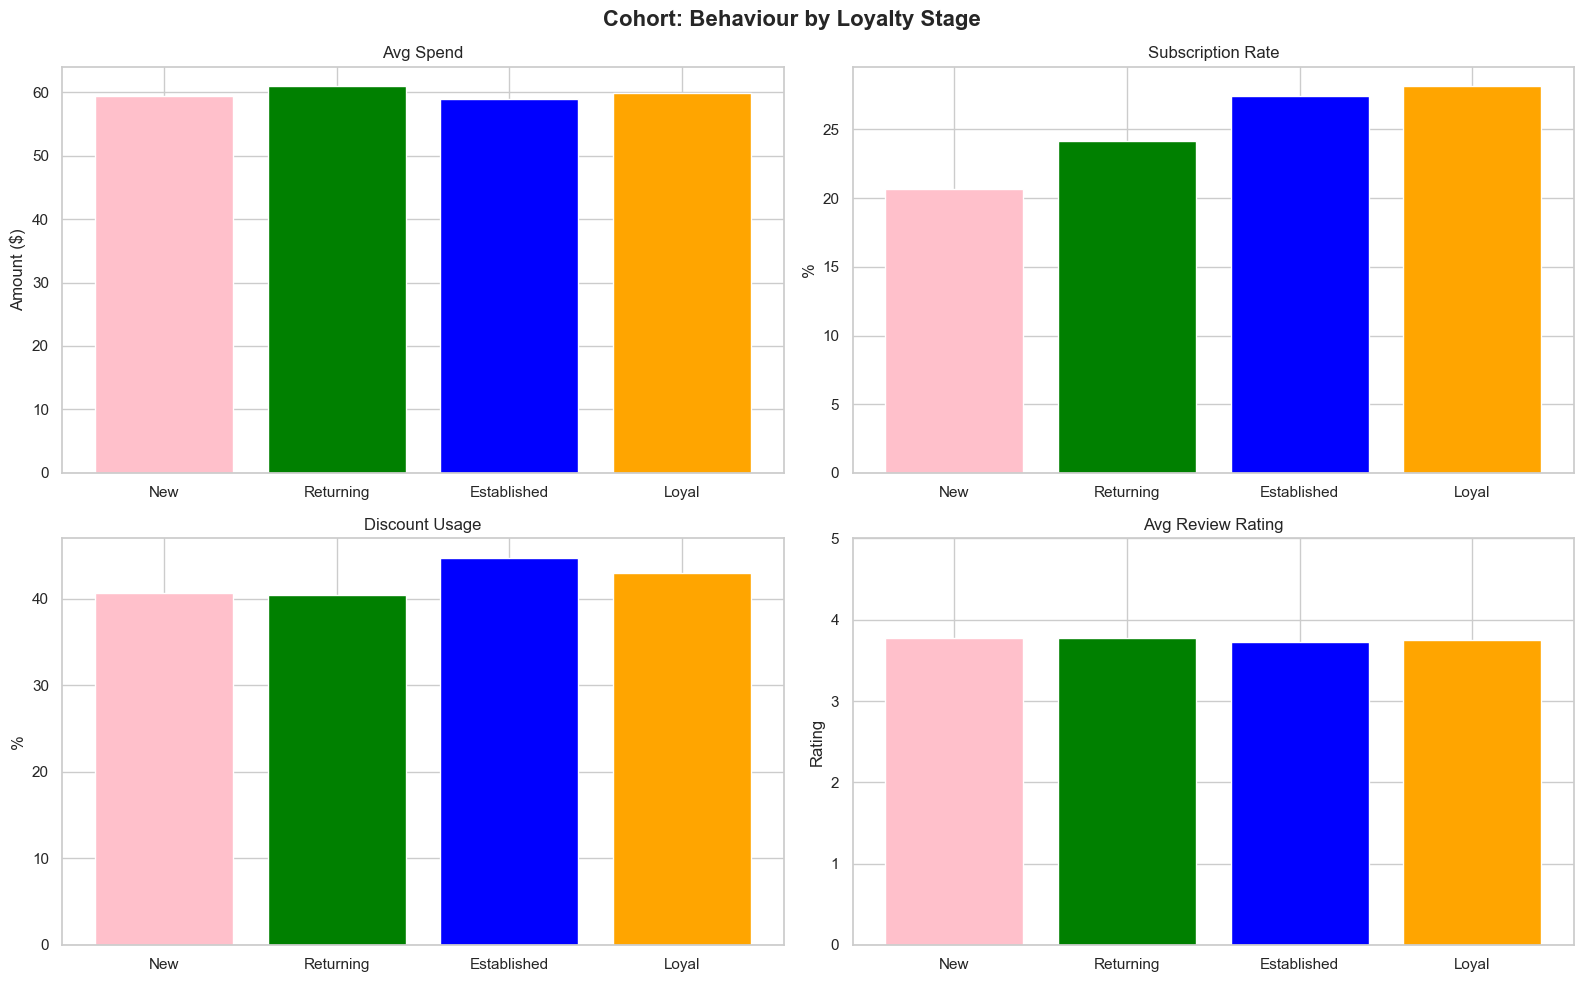

In [244]:
# 9.2 Visualise cohort
stages = [s.split('_')[1] for s in cohort.index]
colors = ['Pink', 'Green', 'Blue', 'Orange']

plt.figure(figsize=(16, 10))
plt.suptitle('Cohort: Behaviour by Loyalty Stage', fontsize=16, fontweight='bold')

plt.subplot(2, 2, 1)
plt.bar(stages, cohort['Avg Spend ($)'], color=colors, edgecolor='white')
plt.title('Avg Spend')
plt.ylabel('Amount ($)')

plt.subplot(2, 2, 2)
plt.bar(stages, cohort['Subscription %'], color=colors, edgecolor='white')
plt.title('Subscription Rate')
plt.ylabel('%')

plt.subplot(2, 2, 3)
plt.bar(stages, cohort['Discount %'], color=colors, edgecolor='white')
plt.title('Discount Usage')
plt.ylabel('%')

plt.subplot(2, 2, 4)
plt.bar(stages, cohort['Avg Rating'], color=colors, edgecolor='white')
plt.title('Avg Review Rating')
plt.ylabel('Rating')
plt.ylim(0, 5)

plt.tight_layout()
plt.savefig('cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [210]:
# 10. FUNNEL ANALYSIS(DISCOUNT)

In [212]:
# 10.1 Build funnel
total = len(df)
avg_spend = df['purchase_amount'].mean()

discount_users = df[df['discount_applied'] == 'Yes']
high_value = discount_users[discount_users['purchase_amount'] >= avg_spend]
subscribed = high_value[high_value['subscription_status'] == 'Yes']

funnel = {
    'All Customers': total,
    'Used Discount': len(discount_users),
    'Spent Above Average': len(high_value),
    'Also Subscribed': len(subscribed)
}

for stage, count in funnel.items():
    print(f'{stage}: {count:,} ({count/total*100:.1f}%)')

All Customers: 3,900 (100.0%)
Used Discount: 1,677 (43.0%)
Spent Above Average: 839 (21.5%)
Also Subscribed: 529 (13.6%)


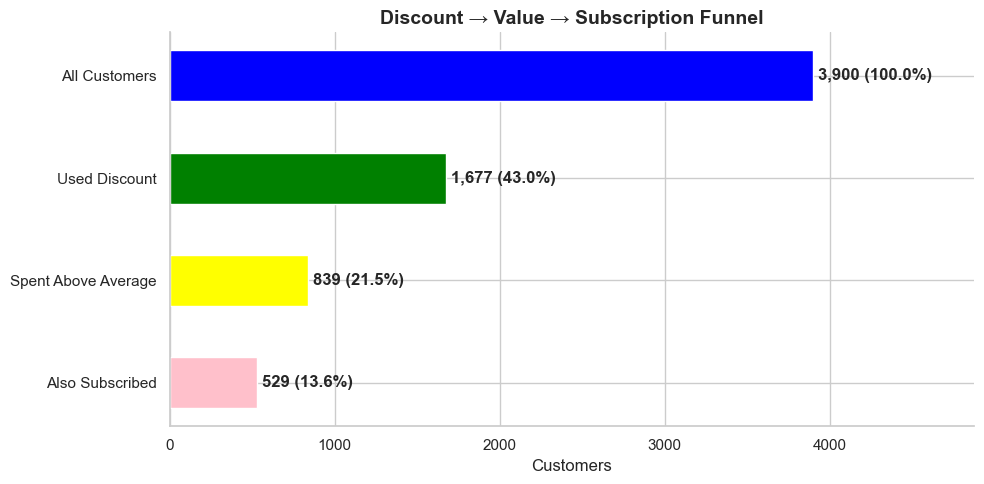

In [246]:
# 10.2 Visualise funnel
colors = ['Blue', 'Green', 'Yellow', 'Pink']
stages = list(funnel.keys())
values = list(funnel.values())

plt.figure(figsize=(10, 5))
bars = plt.barh(stages[::-1], values[::-1],
                color=colors[::-1], edgecolor='white', height=0.5)

for bar, val in zip(bars, values[::-1]):
    plt.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
             f'{val:,} ({val/total*100:.1f}%)', va='center', fontweight='bold')

plt.title('Discount → Value → Subscription Funnel', fontsize=14, fontweight='bold')
plt.xlabel('Customers')
plt.xlim(0, total * 1.25)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('discount_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 11. Export to MySQL

In [216]:
# 11.1 Final check before export
print('Final columns:')
print(df.columns.tolist())
print(f'\nFinal shape: {df.shape}')
df.head(3)

Final columns:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'previous_purchases', 'payment_method', 'frequency_of_purchases', 'age_group', 'purchase_frequency_days', 'spend_tier', 'loyalty_stage', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_segment', 'cluster', 'cluster_label']

Final shape: (3900, 28)


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,spend_tier,loyalty_stage,r_score,f_score,m_score,rfm_score,rfm_segment,cluster,cluster_label
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Mid-aged (46-57),14,Mid Spender,3_Established,4,2,2,8,Loyal Customers,1,Mid Range
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult (18-30),14,Mid Spender,1_New,4,1,3,8,Loyal Customers,1,Mid Range
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Mid-aged (46-57),7,High Spender,3_Established,4,2,3,9,Loyal Customers,1,Mid Range


In [248]:
# 11.2 Save enriched CSV as backup
df.to_csv('customer_enriched.csv', index=False)
print('Saved as customer_enriched.csv')


Saved as customer_enriched.csv


In [256]:
print(df.columns.tolist())

['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'previous_purchases', 'payment_method', 'frequency_of_purchases', 'age_group', 'purchase_frequency_days', 'spend_tier', 'loyalty_stage', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_segment', 'cluster', 'cluster_label']


In [254]:
# 11.3 Push enriched data to MySQL
username = 'root'
password = 'Mysql_08'    
host     = 'localhost'
port     = '3306'
database = 'customer_behaviour'

engine = create_engine(f'mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}')

df.to_sql('customer', engine, if_exists='replace', index=False)
print(f" Data loaded into '{database}.customer'")
print(f'Total rows exported: {len(df):,}')

 Data loaded into 'customer_behaviour.customer'
Total rows exported: 3,900
